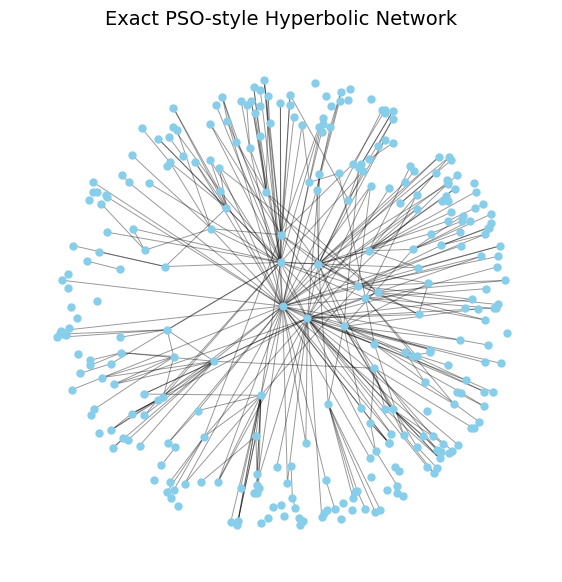

In [51]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

N = 300
m = 3
beta = 0.5
T = 0.5
zeta = 1.0

R = (2 / zeta) * np.log(N / m)

def hyperbolic_dist(ru, rv, theta, phi):
    Δ = np.pi - abs(np.pi - abs(theta - phi))
    return (1 / zeta) * np.arccosh(
        np.cosh(zeta * ru) * np.cosh(zeta * rv) -
        np.sinh(zeta * ru) * np.sinh(zeta * rv) * np.cos(Δ)
    )

def p_conn(d):
    return 1 / (1 + np.exp((d - R) / (T * 2)))

G = nx.Graph()
rs, thetas = [], []
positions = {}


for t in range(1, N + 1):
    r_t = (2 / zeta) * np.log(t)
    theta_t = np.random.uniform(0, 2*np.pi)

    G.add_node(t)
    rs.append(r_t)
    thetas.append(theta_t)
    positions[t] = (r_t * np.cos(theta_t), r_t * np.sin(theta_t))

    # d  to e nodes
    dists = [hyperbolic_dist(r_t, rs[j], theta_t, thetas[j]) for j in range(t - 1)]
    probs = [p_conn(d) for d in dists]

    if t - 1 <= m:
        targets = range(t - 1)
    else:
        idxs = np.arange(t - 1)
        targets = np.random.choice(idxs, size=m, replace=False, p=np.array(probs)/sum(probs))

    for j in targets:
        if np.random.rand() < probs[j]:
            G.add_edge(t, j+1)

plt.figure(figsize=(7,7))
nx.draw_networkx_nodes(G, positions, node_size=25, node_color='skyblue')
nx.draw_networkx_edges(G, positions, alpha=0.4, width=0.7)
plt.title("Exact PSO‑style Hyperbolic Network", fontsize=14)
plt.axis('off')
plt.show()
